In [48]:
!pip install rasterio
import random
import os
import json
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models,mixed_precision
import tensorflow.keras.backend as K
from rasterio.enums import Resampling
from sklearn.metrics import f1_score, jaccard_score,precision_score, recall_score,confusion_matrix,accuracy_score
import scipy.ndimage as ndimage
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc
from tensorflow.keras.layers import TimeDistributed,GlobalAveragePooling2D,\
                                    Dense,Conv2D,Input,ConvLSTM2D,LayerNormalization,\
                                    MaxPooling2D,Concatenate,UpSampling2D,Activation,Layer

from tensorflow.keras.models import Model
from collections import defaultdict
import seaborn as sns
import warnings
from tensorflow.keras import metrics as tf_metrics

warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)



In [128]:
from tqdm.auto import tqdm
def safe_serialize(obj):
    if isinstance(obj, (list, tuple)):
        return [safe_serialize(x) for x in obj]
    elif isinstance(obj, dict):
        return {k: safe_serialize(v) for k, v in obj.items()}
    elif hasattr(obj, '__dict__'):
        return str(obj)
    elif isinstance(obj, (np.integer, np.floating, np.bool_)):
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

def read_tif_metadata(filepath):
    try:
        with rasterio.open(filepath) as src:
            meta = {
                'Dimensiones': src.shape,
                'bandas': src.count,
                'CRS': str(src.crs) if src.crs else "unknown",
                'Resolución': [float(x) for x in src.res],
                'límites': [float(x) for x in src.bounds],
                'Driver': src.driver,
                'Compresión': str(src.compression) if src.compression else None,
                'Tipo de dato': str(src.dtypes[0]),
                'Nodata_value': safe_serialize(src.nodata),
                'Descripciones': list(src.descriptions) if src.descriptions else None,
            }

            tags = dict(src.tags()) if src.tags() else None
            profile = safe_serialize(dict(src.profile))

            return {
                'metadata': meta,
                'tags': tags,
                'profile': profile
            }
    except Exception as e:
        return {'error': str(e)}


carpetas = ['ESRI_LULC', 'FirePred', 'VIIRS_Day', 'VIIRS_Night']
base = '/kaggle/input/ts-satfire/ts-satfire/'

print("Analizando estructura de directorios...")
all_dirs = [os.path.join(base, d) for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
total_dirs = len(all_dirs)


data = {
    "dataset": "TS-SatFire",
    "base_path": base,
    "total_directories": total_dirs,
    "directories": {},
    "summary": {
        "global_stats": defaultdict(int),
        "dimensiones": defaultdict(int),
        "bandas": defaultdict(int),
        "crs": defaultdict(int),
    }
}


for dir_path in tqdm(all_dirs, desc="Directorios"):
    dir_name = os.path.basename(dir_path)
    data["directories"][dir_name] = {
        "path": dir_path,
        "folders": {}
    }

    for folder in carpetas:
        folder_path = os.path.join(dir_path, folder)
        exists = os.path.isdir(folder_path)
        data["directories"][dir_name]["folders"][folder] = {
            "exists": exists,
            "tif_count": 0,
            "files": []
        }

        if not exists:
            continue

        tif_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.tif', '.tiff'))]
        data["directories"][dir_name]["folders"][folder]["tif_count"] = len(tif_files)

        for tif_name in tqdm(tif_files, desc=f"{dir_name}/{folder}", leave=False):
            tif_path = os.path.join(folder_path, tif_name)
            info = read_tif_metadata(tif_path)
            
            file_entry = {
                "name": tif_name,
                "path": tif_path
            }
            file_entry.update(info)  

            data["directories"][dir_name]["folders"][folder]["files"].append(file_entry)


            if 'error' not in info:
                meta = info['metadata']
                dims = f"{meta['Dimensiones'][0]}x{meta['Dimensiones'][1]}"
                
                data["summary"]["global_stats"]["total_tif_files"] += 1
                data["summary"]["dimensiones"][dims] += 1
                data["summary"]["bandas"][meta['bandas']] += 1
                data["summary"]["crs"][meta['CRS']] += 1
                data["summary"]["global_stats"][f"tiene_{folder}"] = data["summary"]["global_stats"].get(f"tiene_{folder}", 0) + 1


print("\nGuardando resultados...")

with open('metadata_analysis.json', 'w') as f:
    json.dump(data, f, indent=2, default=str)


Analizando estructura de directorios...


Directorios:   0%|          | 0/192 [00:00<?, ?it/s]

21889719/ESRI_LULC:   0%|          | 0/1 [00:00<?, ?it/s]

24333270/ESRI_LULC:   0%|          | 0/1 [00:00<?, ?it/s]

24333270/FirePred:   0%|          | 0/10 [00:00<?, ?it/s]

...

24462263/ESRI_LULC:   0%|          | 0/1 [00:00<?, ?it/s]

24462263/FirePred:   0%|          | 0/26 [00:00<?, ?it/s]

24462263/VIIRS_Day:   0%|          | 0/26 [00:00<?, ?it/s]

24462263/VIIRS_Night:   0%|          | 0/26 [00:00<?, ?it/s]


Guardando resultados...


In [5]:

data = json.load(open('/kaggle/working/metadata_analysis.json'))

In [6]:

def analyze(data, union=set()):
    total = 0
    seq_day = []
    seq_night = []
    fire_pred = []
    path_valid = set() 

    for dir_name, dir_info in data["directories"].items():
        path = dir_info["path"]
        
        if path in union:
            continue
            
        path_valid.add(path)

        folders = dir_info["folders"]

        day_count = folders.get("VIIRS_Day", {}).get("tif_count", 0)
        night_count = folders.get("VIIRS_Night", {}).get("tif_count", 0)
        pred_count = folders.get("FirePred", {}).get("tif_count", 0)

        seq_day.append(day_count)
        seq_night.append(night_count)
        fire_pred.append(pred_count)

        total += day_count + night_count + pred_count

    seq_day = np.array(seq_day)
    seq_night = np.array(seq_night)
    fire_pred = np.array(fire_pred)

    return seq_day, seq_night, fire_pred, total, path_valid

seq_day,seq_night,fire_pred,total,path_valid = analyze(data)

In [7]:
total

10647

In [8]:

paths_list = list(path_valid) 


mask = (seq_day > 0) & (seq_night > 0) & (fire_pred > 0)

seq_day_clean   = seq_day[mask]
seq_night_clean = seq_night[mask]
fire_pred_clean = fire_pred[mask]
paths_clean     = [p for i, p in enumerate(paths_list) if mask[i]]


In [9]:
print(len(seq_day_clean),len(seq_night_clean),len(fire_pred_clean))

178 178 178


In [10]:
c=seq_day_clean == seq_night_clean
seq_day_clean[~c]

array([20, 87, 37, 74, 49, 66, 58, 23, 55])

In [11]:
seq_night_clean[~c]

array([19, 83, 29, 69, 41, 59, 52, 19, 50])

In [12]:
fire_delete = set()

for dir_name, dir_info in data["directories"].items():
    folders = dir_info["folders"]
    
    tiene_fire = folders.get("FirePred", {}).get("exists", False)
    tiene_day  = folders.get("VIIRS_Day", {}).get("exists", False)
    
    if tiene_fire and not tiene_day:
        fire_delete.add(dir_info["path"]) 

In [13]:
fire_delete1 = set()
for dir_name, dir_info in data["directories"].items():
    folders = dir_info["folders"]
    
    tiene_fire = folders.get("FirePred", {}).get("exists", False)
    tiene_day  = folders.get("VIIRS_Night", {}).get("exists", False)
    
    if tiene_fire and not tiene_day:
        fire_delete1.add(dir_info["path"]) 

In [14]:
fire_delete1

{'/kaggle/input/ts-satfire/ts-satfire/24332700'}

In [15]:
fire_delete

{'/kaggle/input/ts-satfire/ts-satfire/24332700'}

In [16]:
delete = set()

for dir_name, dir_info in data["directories"].items():
    folders = dir_info["folders"]
    
    has_day   = folders.get("VIIRS_Day", {}).get("exists", False)
    has_night = folders.get("VIIRS_Night", {}).get("exists", False)
    has_fire  = folders.get("FirePred", {}).get("exists", False)
    
    if not (has_day and has_night and has_fire):
        delete.add(dir_info["path"])  
        continue
    
    day_count   = folders["VIIRS_Day"]["tif_count"]
    night_count = folders["VIIRS_Night"]["tif_count"]
    
    if day_count != night_count:
        delete.add(dir_info["path"])

In [17]:
len(delete)

23

In [18]:
union = fire_delete.union(delete).union(fire_delete1)
len(union)

23

In [19]:
seq_day,seq_night,fire_pred,total,path_valid = analyze(data,union=union)

In [21]:
val_ids = ['20568194', '20701026','20562846','20700973','24462610', '24462788', '24462753', '24103571', '21998313', '21751303', '22141596', '21999381', '23301962', '22712904', '22713339']
val = []
ids=[]
a=0
print(len(val_ids))
for path in path_valid:
    id = path.split("/")[-1]
    if id in val_ids:
        val.append(path)
        ids.append(id)
        a+=1
   

print(a)

15
12


In [22]:
val_=[]
for x in val_ids:
    if x not in ids:
        val_.append(x)

In [23]:
val_

['24462753', '23301962', '22713339']

In [24]:
for i in union:
    s = i.split('/')[-1]
    if s in val_:
        print(i)

/kaggle/input/ts-satfire/ts-satfire/24462753
/kaggle/input/ts-satfire/ts-satfire/22713339


In [25]:
print(os.listdir('/kaggle/input/ts-satfire/ts-satfire/22713339'))
print(os.listdir('/kaggle/input/ts-satfire/ts-satfire/24462753'))

['ESRI_LULC']
['VIIRS_Night', 'FirePred', 'VIIRS_Day']


In [26]:
for i in os.listdir('/kaggle/input/ts-satfire/ts-satfire/24462753'):
    path = os.path.join('/kaggle/input/ts-satfire/ts-satfire/24462753',i)
    print(len(os.listdir(path)))

19
20
20


In [27]:
val.append('/kaggle/input/ts-satfire/ts-satfire/24462753')

In [28]:
test = [ x for x in path_valid if x.split('/')[-1].startswith('US')]

In [25]:
import rasterio
import os
from pathlib import Path

def analizar_canales_tif(path):
    """
    Recibe un path, busca todos los archivos .tif y muestra 
    la cantidad de canales (bandas) y dimensiones de cada uno.
    """
    folder = Path(path)
    if not folder.exists():
        print(f"[!] Error: El path {path} no existe.")
        return

    tifs = list(folder.glob('*.tif'))
    tifs.sort() # Ordenar para que coincidan con tu lógica de secuencias

    if not tifs:
        print(f"[*] No se encontraron archivos .tif en: {path}")
        return

    print(f"[*] Analizando {len(tifs)} archivos en: {path}\n")
    print(f"{'Archivo':<40} | {'Canales':<8} | {'Dimensiones':<15}")
    print("-" * 70)

    resumen_canales = {}

    for tif_path in tifs:
        try:
            with rasterio.open(tif_path) as src:
                n_channels = src.count
                shape = src.shape # (height, width)
                
                resumen_canales[n_channels] = resumen_canales.get(n_channels, 0) + 1
                
                print(f"{tif_path.name:<40} | {n_channels:<8} | {str(shape):<15}")
        except Exception as e:
            print(f"[!] Error leyendo {tif_path.name}: {e}")

    print("-" * 70)
    print("[*] Resumen de consistencia:")
    for canales, count in resumen_canales.items():
        print(f"    - {count} archivos tienen {canales} canales.")

base_path = ['/kaggle/input/ts-satfire/ts-satfire/swedish_fire/',
             '/kaggle/input/ts-satfire/ts-satfire/sparks_lake_fire',
             '/kaggle/input/ts-satfire/ts-satfire/sydney_fire',
             '/kaggle/input/ts-satfire/ts-satfire/elephant_hill_fire',
            '/kaggle/input/ts-satfire/ts-satfire/chuckegg_creek_fire']

for i in base_path:
    print(i)
    print("=== REVISIÓN DE VIIRS DAY ===")
    analizar_canales_tif(os.path.join(i, 'VIIRS_Day'))
    
    print("\n=== REVISIÓN DE VIIRS NIGHT ===")
    analizar_canales_tif(os.path.join(i, 'VIIRS_Night'))
    
    print("\n=== REVISIÓN DE FIREPRED ===")
    analizar_canales_tif(os.path.join(i, 'FirePred'))

/kaggle/input/ts-satfire/ts-satfire/swedish_fire/
=== REVISIÓN DE VIIRS DAY ===
[*] Analizando 10 archivos en: /kaggle/input/ts-satfire/ts-satfire/swedish_fire/VIIRS_Day

Archivo                                  | Canales  | Dimensiones    
----------------------------------------------------------------------
2018-07-14_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-15_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-16_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-17_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-18_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-19_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-20_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-21_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-22_VIIRS_Day.tif                 | 8        | (596, 594)     
2018-07-23_VIIRS_Day.tif                 | 8        | (596

In [29]:
train = [x for x in path_valid if x not in val and x not in test 
                                         and x!='/kaggle/input/ts-satfire/ts-satfire/swedish_fire' 
                                         and x!='/kaggle/input/ts-satfire/ts-satfire/sparks_lake_fire' 
                                         and x!='/kaggle/input/ts-satfire/ts-satfire/sydney_fire'
                                        and x!='/kaggle/input/ts-satfire/ts-satfire/elephant_hill_fire'
                                        and x!='/kaggle/input/ts-satfire/ts-satfire/chuckegg_creek_fire']

In [30]:
len(train)

136

# hyperparameters

In [31]:

#Dataset
CROP_SIZE = 256         
INPUT_CHANNELS = 28 
INPUT_SEQ_LEN = 3  
STRIDE_T=1

# Training Hyperparameters
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 50 
DROPOUT = 0.3
INPUT_SHAPE = (INPUT_SEQ_LEN,CROP_SIZE,CROP_SIZE,INPUT_CHANNELS)
CLIPNORM =1.0
 
#Atention 
REDUCTION=4

# LOSS
GAMMA=2.0
ALPHA = 0.5
SMOOTH = 1.0

#DIR
BASE_CACHE_DIR = 'saved/data_cache'
last_checkpoint_path = 'saved/checkpoints/last_model_convlstm9.weights.h5'
best_checkpoint_path = 'saved/checkpoints/best_fire_model9_convlstm.weights.h5'
history_path = 'training_history9.json'

# Dataset

In [32]:

class TSDataset:
    def __init__(
        self,
        path_valid,
        cache_dir,
        crop_size=256,
        seq_len=3,
        stride_t=1,
        force_rebuild=False,
    ):
        self.crop_size = crop_size
        self.seq_len = seq_len
        self.stride_t = stride_t
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)

        self.catalog_path = self.cache_dir / f"catalog_flat_s{seq_len}_st{stride_t}_c{crop_size}.json"
        
        self.raw_paths = self._find_tiff_files(path_valid)

        if self.catalog_path.exists() and not force_rebuild:
            print(f"Cargando catálogo plano desde {self.catalog_path}...")
            with open(self.catalog_path, "r") as f:
                self.samples = json.load(f)
        else:
            print("Generando catálogo ...")
            self.samples = self._create_flat_catalog()
            with open(self.catalog_path, "w") as f:
                json.dump(self.samples, f)

        print(f"Dataset listo: {len(self.samples)} muestras.")

    def _find_tiff_files(self, paths):
        r = {}
        for idx, base in enumerate(paths):
            r[idx] = {k: {} for k in ["FirePred", "VIIRS_Day", "VIIRS_Night"]}
            for folder in ["FirePred", "VIIRS_Day", "VIIRS_Night"]:
                p = Path(base, folder)
                if p.is_dir():
                    files = list(p.rglob("*.tif"))
                    # { "2020-09-07": Path_objeto }
                    for f in files:
                        date_key = f.name.split('_')[0] 
                        r[idx][folder][date_key] = f
        return r

    def _create_flat_catalog(self):
        catalog = []
        for region_idx, folders in self.raw_paths.items():
            all_dates = sorted(list(set(
                list(folders["VIIRS_Day"].keys()) + 
                list(folders["VIIRS_Night"].keys()) + 
                list(folders["FirePred"].keys())
            )))
    
            # Iteramos sobre las fechas disponibles
            for i in range(len(all_dates) - self.seq_len):
                window_dates = all_dates[i : i + self.seq_len + 1] # seq + target
                
                catalog.append({
                    "region": region_idx,
                    "dates": window_dates, # Guardamos las fechas, no los índices
                    "sample_id": f"reg{region_idx}_{window_dates[0]}"
                })
        return catalog

    def _normalize(self, x, is_label=False):
        x = np.nan_to_num(x, nan=0.0)
        if is_label:
            return np.clip(x, 0.0, 1.0)
        for c in range(x.shape[0]):
            vmin, vmax = x[c].min(), x[c].max()
            if vmax - vmin > 1e-6:
                x[c] = (x[c] - vmin) / (vmax - vmin)
        return x

    def _load_single_window(self, info):
        region = self.raw_paths[info["region"]]
        dates = info["dates"]
        
        seq_x = []
        # Las primeras N fechas son la entrada (X)
        for t_date in dates[:-1]:
            # 1. Cargar Day y FirePred normal (estos sí están)
            with rasterio.open(region["VIIRS_Day"][t_date]) as dsrc:
                y0, x0 = (dsrc.height - self.crop_size)//2, (dsrc.width - self.crop_size)//2
                win = rasterio.windows.Window(x0, y0, self.crop_size, self.crop_size)
                day = self._normalize(dsrc.read([1,2,3,4,5,6], window=win))
                fire_today = self._normalize(dsrc.read([7], window=win), is_label=True)
            
            with rasterio.open(region["FirePred"][t_date]) as fsrc:
                firep = self._normalize(fsrc.read(window=win))
    
            # 2. CARGAR VIIRS_NIGHT CON INTERPOLACIÓN SI FALTA
            if t_date in region["VIIRS_Night"]:
                with rasterio.open(region["VIIRS_Night"][t_date]) as nsrc:
                    night = self._normalize(nsrc.read(window=win)[-2:])
            else:
                # INTERPOLACIÓN: Buscar fecha anterior y posterior en el calendario global
                print(f"Interpolando fecha faltante: {t_date}")
                idx_actual = dates.index(t_date)
                date_prev = dates[idx_actual - 1]
                date_next = dates[idx_actual + 1]
                
                with rasterio.open(region["VIIRS_Night"][date_prev]) as s1, \
                     rasterio.open(region["VIIRS_Night"][date_next]) as s2:
                    night = (self._normalize(s1.read(window=win)[-2:]) + 
                             self._normalize(s2.read(window=win)[-2:])) / 2.0
    
            x_combined = np.concatenate([day, fire_today, night, firep], axis=0)
            seq_x.append(x_combined)
        #print(region['FirePred'])
        # 3. Target (Última fecha de la lista dates)
        target_date = dates[-1]
        with rasterio.open(region["VIIRS_Day"][target_date]) as dsrc:
            y_target = self._normalize(dsrc.read([7], window=win), is_label=True)
    
        return np.stack(seq_x), y_target

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        info = self.samples[idx]
        cache_f = self.cache_dir / f"{info['sample_id']}.npz"

        try:
            if not cache_f.exists():
                x, y = self._load_single_window(info)
                np.savez_compressed(cache_f, x=x, y=y)
            else:
                data = np.load(cache_f)
                x, y = data["x"], data["y"]
            
            #  [T, C, H, W] -> [T, H, W, C]
            x = np.transpose(x, (0, 2, 3, 1)) 
            # [1, H, W] -> [H, W, 1]
            y = np.transpose(y, (1, 2, 0))
            
            return x.astype(np.float32), y.astype(np.float32)

        except Exception as e:
            print(f"Error en {cache_f}")
            raise 


            

In [33]:
cache_base = Path(BASE_CACHE_DIR)


In [30]:


train_dataset = TSDataset(
    path_valid=train,
    cache_dir=cache_base/'train',      
    crop_size=CROP_SIZE,
    stride_t=STRIDE_T,
    force_rebuild=True
)

val_dataset = TSDataset(
    path_valid=val,
    cache_dir=cache_base/'val',
    crop_size=CROP_SIZE,
    seq_len =INPUT_SEQ_LEN,
    stride_t=STRIDE_T,
    force_rebuild=True
)


Generando catálogo ...
Dataset listo: 1966 muestras.
Generando catálogo ...
Dataset listo: 239 muestras.


In [34]:

def prepare_tf_dataset(py_dataset, batch_size=4, is_train=True):
    def generator():
        for i in range(len(py_dataset)):
            yield py_dataset[i]

    # x: (T, H, W, C), y: (H, W, 1)
    output_signature = (
        tf.TensorSpec(shape=(3, 256, 256, 28), dtype=tf.float32), 
        tf.TensorSpec(shape=(256, 256, 1), dtype=tf.float32)
    )

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=output_signature
    )

    if is_train:
        ds = ds.shuffle(buffer_size=100)
    
    ds = ds.batch(batch_size)
    
    ds = ds.prefetch(tf.data.AUTOTUNE).repeat()
    
    return ds


In [31]:


train_tf_ds = prepare_tf_dataset(train_dataset, batch_size=BATCH_SIZE, is_train=True)
val_tf_ds = prepare_tf_dataset(val_dataset, batch_size=BATCH_SIZE, is_train=False)


I0000 00:00:1769626718.986328      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# model 

In [36]:

class ConvLSTMAttentionBlock(Layer):
    def __init__(self, channels, reduction=4, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

        # Channel attention
        self.avg_pool = TimeDistributed(
            GlobalAveragePooling2D()
        )
        self.fc1 = Dense(channels // reduction, activation='relu')
        self.fc2 = Dense(channels, activation='sigmoid')

        # Spatial attention
        self.spatial_conv = TimeDistributed(
            Conv2D(
                filters=1,
                kernel_size=7,
                padding='same',
                activation='sigmoid'
            )
        )

    def call(self, x):
        # x: (B, T, H, W, C)

        #  Channel Attention 
        c = self.avg_pool(x)              # (B, T, C)
        c = self.fc1(c)                   # (B, T, C//r)
        c = self.fc2(c)                   # (B, T, C)
        c = tf.expand_dims(c, axis=2)     # (B, T, 1, C)
        c = tf.expand_dims(c, axis=2)     # (B, T, 1, 1, C)

        x = x * c

        #  Spatial Attention 
        avg_s = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_s = tf.reduce_max(x, axis=-1, keepdims=True)
        s = tf.concat([avg_s, max_s], axis=-1)

        s = self.spatial_conv(s)          # (B, T, H, W, 1)

        return x * s

def build_convlstm_bottleneck128(
    input_shape=(3, 256, 256, 28),
    dropout=0.3,
    reduction=4
):
    inputs = Input(shape=input_shape)

    #  ENCODER 
    e1 = ConvLSTM2D(
        24, 3, padding='same',
        return_sequences=True,
        dropout=dropout,
    )(inputs)
    e1 = LayerNormalization()(e1)

    p1 = TimeDistributed(MaxPooling2D(2))(e1)

    e2 = ConvLSTM2D(
        48, 3, padding='same',
        return_sequences=True,
        dropout=dropout
    )(p1)
    e2 = LayerNormalization()(e2)

    p2 = TimeDistributed(MaxPooling2D(2))(e2)

    e3 = ConvLSTM2D(
        96, 3, padding='same',
        return_sequences=True,
        dropout=dropout
    )(p2)
    e3 = LayerNormalization()(e3)

    #  BOTTLENECK 
    p3 = TimeDistributed(MaxPooling2D(2))(e3)

    b = ConvLSTM2D(
        128, 3, padding='same',
        return_sequences=True,
        dropout=dropout
    )(p3)
    b = LayerNormalization()(b)
    b = ConvLSTMAttentionBlock(128,reduction=reduction)(b)

    #  DECODER 
    u3 = TimeDistributed(UpSampling2D(2))(b)
    u3 = Concatenate(axis=-1)([u3, e3])
    u3 = ConvLSTM2D(96, 3, padding='same', return_sequences=True)(u3)

    u2 = TimeDistributed(UpSampling2D(2))(u3)
    u2 = Concatenate(axis=-1)([u2, e2])
    u2 = ConvLSTM2D(48, 3, padding='same', return_sequences=True)(u2)
    u2 = ConvLSTMAttentionBlock(48,reduction=reduction)(u2)

    u1 = TimeDistributed(UpSampling2D(2))(u2)
    u1 = Concatenate(axis=-1)([u1, e1])
    u1 = ConvLSTM2D(24, 3, padding='same', return_sequences=True)(u1)
    u1 = ConvLSTMAttentionBlock(24,reduction=reduction)(u1)

    # OUTPUT 
    x = ConvLSTM2D(
        16, 3, padding='same',
        return_sequences=False
    )(u1)

    out = Conv2D(1, 1, padding='same')(x)
    out = Activation('linear', dtype='float32', name='predictions')(out)

    return Model(inputs, out, name="ConvLSTM_UNet_Att128")


In [34]:
build_convlstm_bottleneck128(dropout=DROPOUT).summary()

I0000 00:00:1769633156.551973      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "ConvLSTM_UNet_Att128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3, 256,    │          0 │ -                 │
│ (InputLayer)        │ 256, 28)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 3, 256,    │     45,024 │ input_layer[0][0] │
│ (ConvLSTM2D)        │ 256, 24)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 3, 256,    │         48 │ conv_lstm2d[0][0] │
│ (LayerNormalizatio… │ 256, 24)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 3, 128,    │          0 │ layer_normalizat… │
│ (TimeDistributed)   │ 128, 24)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 3, 128,    │    124,608 │ time_distributed… │
│ (ConvLSTM2D)        │ 128, 48)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 128,    │         96 │ conv_lstm2d_1[0]… │
│ (LayerNormalizatio… │ 128, 48)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 3, 64, 64, │          0 │ layer_normalizat… │
│ (TimeDistributed)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_2       │ (None, 3, 64, 64, │    498,048 │ time_distributed… │
│ (ConvLSTM2D)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 64, 64, │        192 │ conv_lstm2d_2[0]… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 3, 32, 32, │          0 │ layer_normalizat… │
│ (TimeDistributed)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_3       │ (None, 3, 32, 32, │  1,032,704 │ time_distributed… │
│ (ConvLSTM2D)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 32, 32, │        256 │ conv_lstm2d_3[0]… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm_attentio… │ (None, 3, 32, 32, │      8,451 │ layer_normalizat… │
│ (ConvLSTMAttention… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 3, 64, 64, │          0 │ conv_lstm_attent… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3, 64, 64, │          0 │ time_distributed… │
│ (Concatenate)       │ 224)              │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_4       │ (None, 3, 64, 64, │  1,106,304 │ concatenate[0][0] │
│ (ConvLSTM2D)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 3, 128,    │          0 │ conv_lstm2d_4[0]

 Total params: 3,255,588 (12.42 MB)

 Trainable params: 3,255,588 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

# Loss

In [36]:

class DiceLoss(tf.keras.losses.Loss):
    def __init__(self, smooth=1.0, name="dice_loss"):
        super().__init__(name=name)
        self.smooth = smooth

    def call(self, y_true, y_pred):
        # Asegurar tipos de datos
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Aplicar sigmoid si la salida del modelo son logits
        y_pred_prob = tf.nn.sigmoid(y_pred)

        # Aplanar los tensores
        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred_prob, [-1])

        # Cálculo de componentes
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        
        # Fórmula estándar de Dice: (2 * Intersección) / (Suma de elementos de cada set)
        dice = (2. * intersection + self.smooth) / (
            tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + self.smooth
        )

        return 1 - dice

# Callback

In [37]:
class SaveHistoryCallback(tf.keras.callbacks.Callback):
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath
        self.history_dict = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = float(self.model.optimizer.learning_rate.numpy())

        current_logs = {
            "epoch": epoch + 1,
            "lr": lr,
        **{k: float(v) for k, v in logs.items()}}
        self.history_dict.append(current_logs)
        
        with open(self.filepath, 'w') as f:
            json.dump(self.history_dict, f, indent=4)

class VisualVerifyCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, save_dir='visual_logs2'):
        super().__init__()
        self.dataset = dataset
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        # Tomar un batch de validación
        for inputs, targets in self.dataset.take(1):
            preds = self.model.predict(inputs, verbose=0)
            preds = tf.nn.sigmoid(preds).numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Frame de entrada (Canal 0 del último paso temporal)
            axes[0].imshow(inputs[0, -1, :, :, 0], cmap='viridis')
            axes[0].set_title("Input (Last Frame)")
            
            # Máscara Real
            axes[1].imshow(targets[0, :, :, 0], cmap='inferno')
            axes[1].set_title("Ground Truth")
            
            # Predicción
            axes[2].imshow(preds[0, :, :, 0], cmap='inferno')
            axes[2].set_title(f"Prediction (Epoch {epoch+1})")
            
            for ax in axes: ax.axis('off')
            
            plt.savefig(f"{self.save_dir}/epoch_{epoch+1}.png")
            plt.close()



# Metrics

In [38]:
class TolerantRecall(tf.keras.metrics.Metric):
    def __init__(self, tol_ksize=5, threshold=0.5, name="tolerant_recall", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tol_ksize = tol_ksize
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.nn.sigmoid(y_pred)
        y_pred_bin = tf.cast(y_pred > self.threshold, tf.float32)

        tp = tf.reduce_sum(y_pred_bin * y_true)
        y_pred_tol = tf.nn.max_pool2d(y_pred_bin, ksize=self.tol_ksize, strides=1, padding='SAME')
        fn = tf.reduce_sum(y_true * (1.0 - y_pred_tol))

        self.tp.assign_add(tp)
        self.fn.assign_add(fn)

    def result(self):
        return self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())

    def reset_state(self):
        self.tp.assign(0.0)
        self.fn.assign(0.0)



class TolerantFalseNegatives(tf.keras.metrics.Metric):
    def __init__(self, tol_ksize=5, threshold=0.5, name="tolerant_fn", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tol_ksize = tol_ksize
        self.threshold = threshold

        self.fn = self.add_weight(name="fn", initializer="zeros", dtype=tf.float32)
        self.pos = self.add_weight(name="pos", initializer="zeros", dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)


        y_pred_bin = tf.cast(tf.nn.sigmoid(y_pred) > self.threshold, tf.float32)

        y_pred_tol = tf.nn.max_pool2d(
            y_pred_bin,
            ksize=self.tol_ksize,
            strides=1,
            padding='SAME'
        )

        fn = tf.reduce_sum(y_true * (1.0 - y_pred_tol))
        pos = tf.reduce_sum(y_true)

        self.fn.assign_add(fn)
        self.pos.assign_add(pos)

    def result(self):
        return self.fn / (self.pos + tf.keras.backend.epsilon())

    def reset_state(self):
        self.fn.assign(0.0)
        self.pos.assign(0.0)

            
class TolerantF1Score(tf.keras.metrics.Metric):
    def __init__(self, tol_ksize=5, threshold=0.5, name="tolerant_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tol_ksize = tol_ksize
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = tf.cast(tf.nn.sigmoid(y_pred) > self.threshold, tf.float32)
        
        y_true_tol = tf.nn.max_pool2d(y_true, ksize=self.tol_ksize, strides=1, padding='SAME')
   
        y_pred_tol = tf.nn.max_pool2d(y_pred_bin, ksize=self.tol_ksize, strides=1, padding='SAME')

        tp = tf.reduce_sum(y_pred_bin * y_true)
        fp = tf.reduce_sum(y_pred_bin * (1.0 - y_true_tol))
        fn = tf.reduce_sum(y_true * (1.0 - y_pred_tol))

        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        precision = self.tp / (self.tp + self.fp + tf.keras.backend.epsilon())
        recall = self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())
        
        f1 = 2 * ((precision * recall) / (precision + recall + tf.keras.backend.epsilon()))
        return f1

    def reset_state(self):
        self.tp.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)





class BinaryF1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.f1 = tf.keras.metrics.F1Score(
            name='f1', 
            threshold=threshold, 
            average='weighted'
        )
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Aplanar las dimensiones espaciales (height, width)
        y_true_flat = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
        y_pred_flat = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
        
        # Actualizar métrica F1
        self.f1.update_state(y_true_flat, y_pred_flat, sample_weight)
        
    def result(self):
        return self.f1.result()
        
    def reset_state(self):
        self.f1.reset_state()


In [39]:

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: ',policy.compute_dtype)
print('Variable dtype: ',policy.variable_dtype)


def main(train_tf_ds,val_tf_ds):
    os.makedirs('saved/checkpoints1', exist_ok=True)

   
    metrics = [
     
        TolerantRecall(name="tol_recall"),
        TolerantFalseNegatives(name="tol_fn"),
        TolerantF1Score(name="tol_f1_score"), 
        
        BinaryF1Score(name="f1_score", threshold=0.5),
        tf.keras.metrics.BinaryIoU(target_class_ids=[1], name="iou"), 
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Recall(name="recall"),    
        tf.keras.metrics.FalseNegatives(name="fn") 
    ]

    model = build_convlstm_bottleneck128(input_shape=INPUT_SHAPE,dropout=DROPOUT,reduction=REDUCTION)

    initial_epoch = 0
    best_val_f1 = -1.0 
    history_cb = SaveHistoryCallback(history_path)

    if os.path.exists(history_path):
        try:
            with open(history_path, 'r') as f:
                saved_history = json.load(f)
                history_cb.history_dict = saved_history
                if saved_history:
                    initial_epoch = saved_history[-1]['epoch']
                    f1_values = [h.get('val_f1_score', -1.0) for h in saved_history]
                    best_val_f1 = max(f1_values)
                    print(f"[*] Historial cargado. Reanudando en época {initial_epoch + 1}")
                    print(f"[*] Mejor val_f1 histórico: {best_val_f1:.4f}")
        except Exception as e:
            print(f"[!] Error cargando historial: {e}")

    if os.path.exists(last_checkpoint_path):
        print(f"[*] Cargando pesos recientes: {last_checkpoint_path}")
        model.load_weights(last_checkpoint_path)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM),
        loss=DiceLoss(smooth=SMOOTH),
        metrics=metrics
    )


    best_ckpt_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=best_checkpoint_path,
        monitor='val_f1_score', 
        mode='max',            
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    if best_val_f1 != -1.0:
        best_ckpt_callback.best = best_val_f1

    callbacks = [
        best_ckpt_callback,
        history_cb,
        VisualVerifyCallback(val_tf_ds),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=last_checkpoint_path,
            save_best_only=False,
            save_weights_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]

    print(f"\nIniciando entrenamiento")

    steps_per_epoch = len(train_dataset) // BATCH_SIZE
    validation_steps = len(val_dataset) // BATCH_SIZE
    
    model.fit(
        train_tf_ds,
        steps_per_epoch=steps_per_epoch,     
        validation_data=val_tf_ds,
        validation_steps=validation_steps,   
        epochs=EPOCHS,
        initial_epoch=initial_epoch,
        callbacks=callbacks
    )

Compute dtype:  float16
Variable dtype:  float32


In [165]:
main(train_tf_ds,val_tf_ds)


Iniciando entrenamiento
Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9763 - f1_score: 0.0262 - fn: 290095.1562 - iou: 0.0134 - loss: 0.9793 - precision: 0.0165 - recall: 0.0870 - tol_f1_score: 0.0144 - tol_fn: 0.2285 - tol_recall: 0.7448Interpolando fecha faltante: 2020-09-17
Interpolando fecha faltante: 2020-09-17
Interpolando fecha faltante: 2020-09-17

Epoch 1: val_f1_score improved from -inf to 0.17928, saving model to saved/checkpoints/best_fire_model8_convlstm.weights.h5

Epoch 1: saving model to saved/checkpoints/last_model_convlstm8.weights.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 2668s 10s/step - accuracy: 0.9763 - f1_score: 0.0263 - fn: 291288.0625 - iou: 0.0134 - loss: 0.9792 - precision: 0.0166 - recall: 0.0873 - tol_f1_score: 0.0144 - tol_fn: 0.2295 - tol_recall: 0.7437 - val_accuracy: 0.9954 - val_f1_score: 0.1793 - val_fn: 44660.0000 - val_iou: 0.0985 - val_loss: 0.9063 - val_precision: 0.2314 - val_recall: 0.1463 - val_tol_f1_score: 0.2355 - val_tol_fn: 0.70

KeyboardInterrupt: 

# eval

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_json('/kaggle/working/training_history8.json')


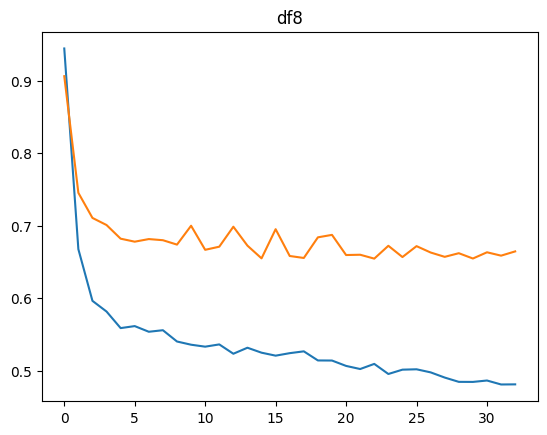

In [40]:
plt.plot(df['loss'])
plt.plot(df['val_loss'])
plt.title("df8")
plt.savefig('fig8')

In [41]:
class InferenceTS(TSDataset):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.target_size = 512
        self.patch_size = 256

    def _read_and_rescale(self, dataset, bands, is_label=False):
        resampling_mode = Resampling.nearest if is_label else Resampling.bilinear
        band_indices = bands if bands is not None else list(range(1, dataset.count + 1))
        
        data = dataset.read(
            band_indices,
            out_shape=(len(band_indices), self.target_size, self.target_size),
            resampling=resampling_mode
        )
        return self._normalize(data, is_label=is_label)

    def __getitem__(self, idx):
        info = self.samples[idx]
        region = self.raw_paths[info["region"]]
        dates = info["dates"] 

        full_seq_512 = [] 
        for t_date in dates[:-1]:
            # VIIRS Day 
            with rasterio.open(region["VIIRS_Day"][t_date]) as dsrc:
                day = self._read_and_rescale(dsrc, [1, 2, 3, 4, 5, 6])
                fire_today = self._read_and_rescale(dsrc, [7], is_label=True)

            # VIIRS Night
            if t_date in region["VIIRS_Night"]:
                with rasterio.open(region["VIIRS_Night"][t_date]) as nsrc:
                    num_bands = nsrc.count
                    night = self._read_and_rescale(nsrc, [num_bands-1, num_bands])
            else:
                night = np.zeros((2, self.target_size, self.target_size), dtype=np.float32)

            # FirePred
            with rasterio.open(region["FirePred"][t_date]) as fsrc:
                firep = self._read_and_rescale(fsrc, None)

            combined_t = np.concatenate([day, fire_today, night, firep], axis=0)
            full_seq_512.append(combined_t)

        full_seq_tensor = np.stack(full_seq_512)

        patches = []
        offsets = [(0, 0), (0, 256), (256, 0), (256, 256)]
        for (y, x) in offsets:
            patch = full_seq_tensor[:, :, y:y+256, x:x+256]
            patches.append(patch)

        return {
            "patches": np.stack(patches), # [4, T, C, 256, 256]
            "sample_id": info['sample_id']
        }

    def predict_full_image(self, model, patches_tensor):
        """
        Predice los 4 parches y los une en una imagen de 512x512.
        """

        
        patches_tf = np.transpose(patches_tensor, (0, 1, 3, 4, 2))
        
        preds = []
        for i in range(4):
            patch = patches_tf[i:i+1] # (1, T, 256, 256, C)
            p = model.predict(patch, verbose=0)
            

            p_prob = tf.nn.sigmoid(p).numpy()
            preds.append(np.squeeze(p_prob)) # (256, 256)

        # Reconstrucción de la cuadrícula 2x2
        top = np.concatenate([preds[0], preds[1]], axis=1)
        bottom = np.concatenate([preds[2], preds[3]], axis=1)
        return np.concatenate([top, bottom], axis=0) # [512, 512]

    def get_ground_truth(self, idx):
        info = self.samples[idx]
        region = self.raw_paths[info["region"]]
        target_date = info["dates"][-1]
        
        with rasterio.open(region["VIIRS_Day"][target_date]) as dsrc:
            y_true = dsrc.read(
                7, 
                out_shape=(self.target_size, self.target_size), 
                resampling=Resampling.nearest
            )
            return self._normalize(y_true, is_label=True)

I0000 00:00:1769611582.352933      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


[*] Pesos cargados correctamente desde saved/checkpoints/best_fire_model8_convlstm.weights.h5
Generando catálogo ...
Dataset listo: 357 muestras.
Iniciando Inferencia Completa en 357 muestras...


  0%|          | 0/357 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1769611593.013535     108 service.cc:152] XLA service 0x1f6cd510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769611593.013571     108 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769611594.369656     108 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769611598.481737     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 357/357 [13:24<00:00,  2.25s/it]


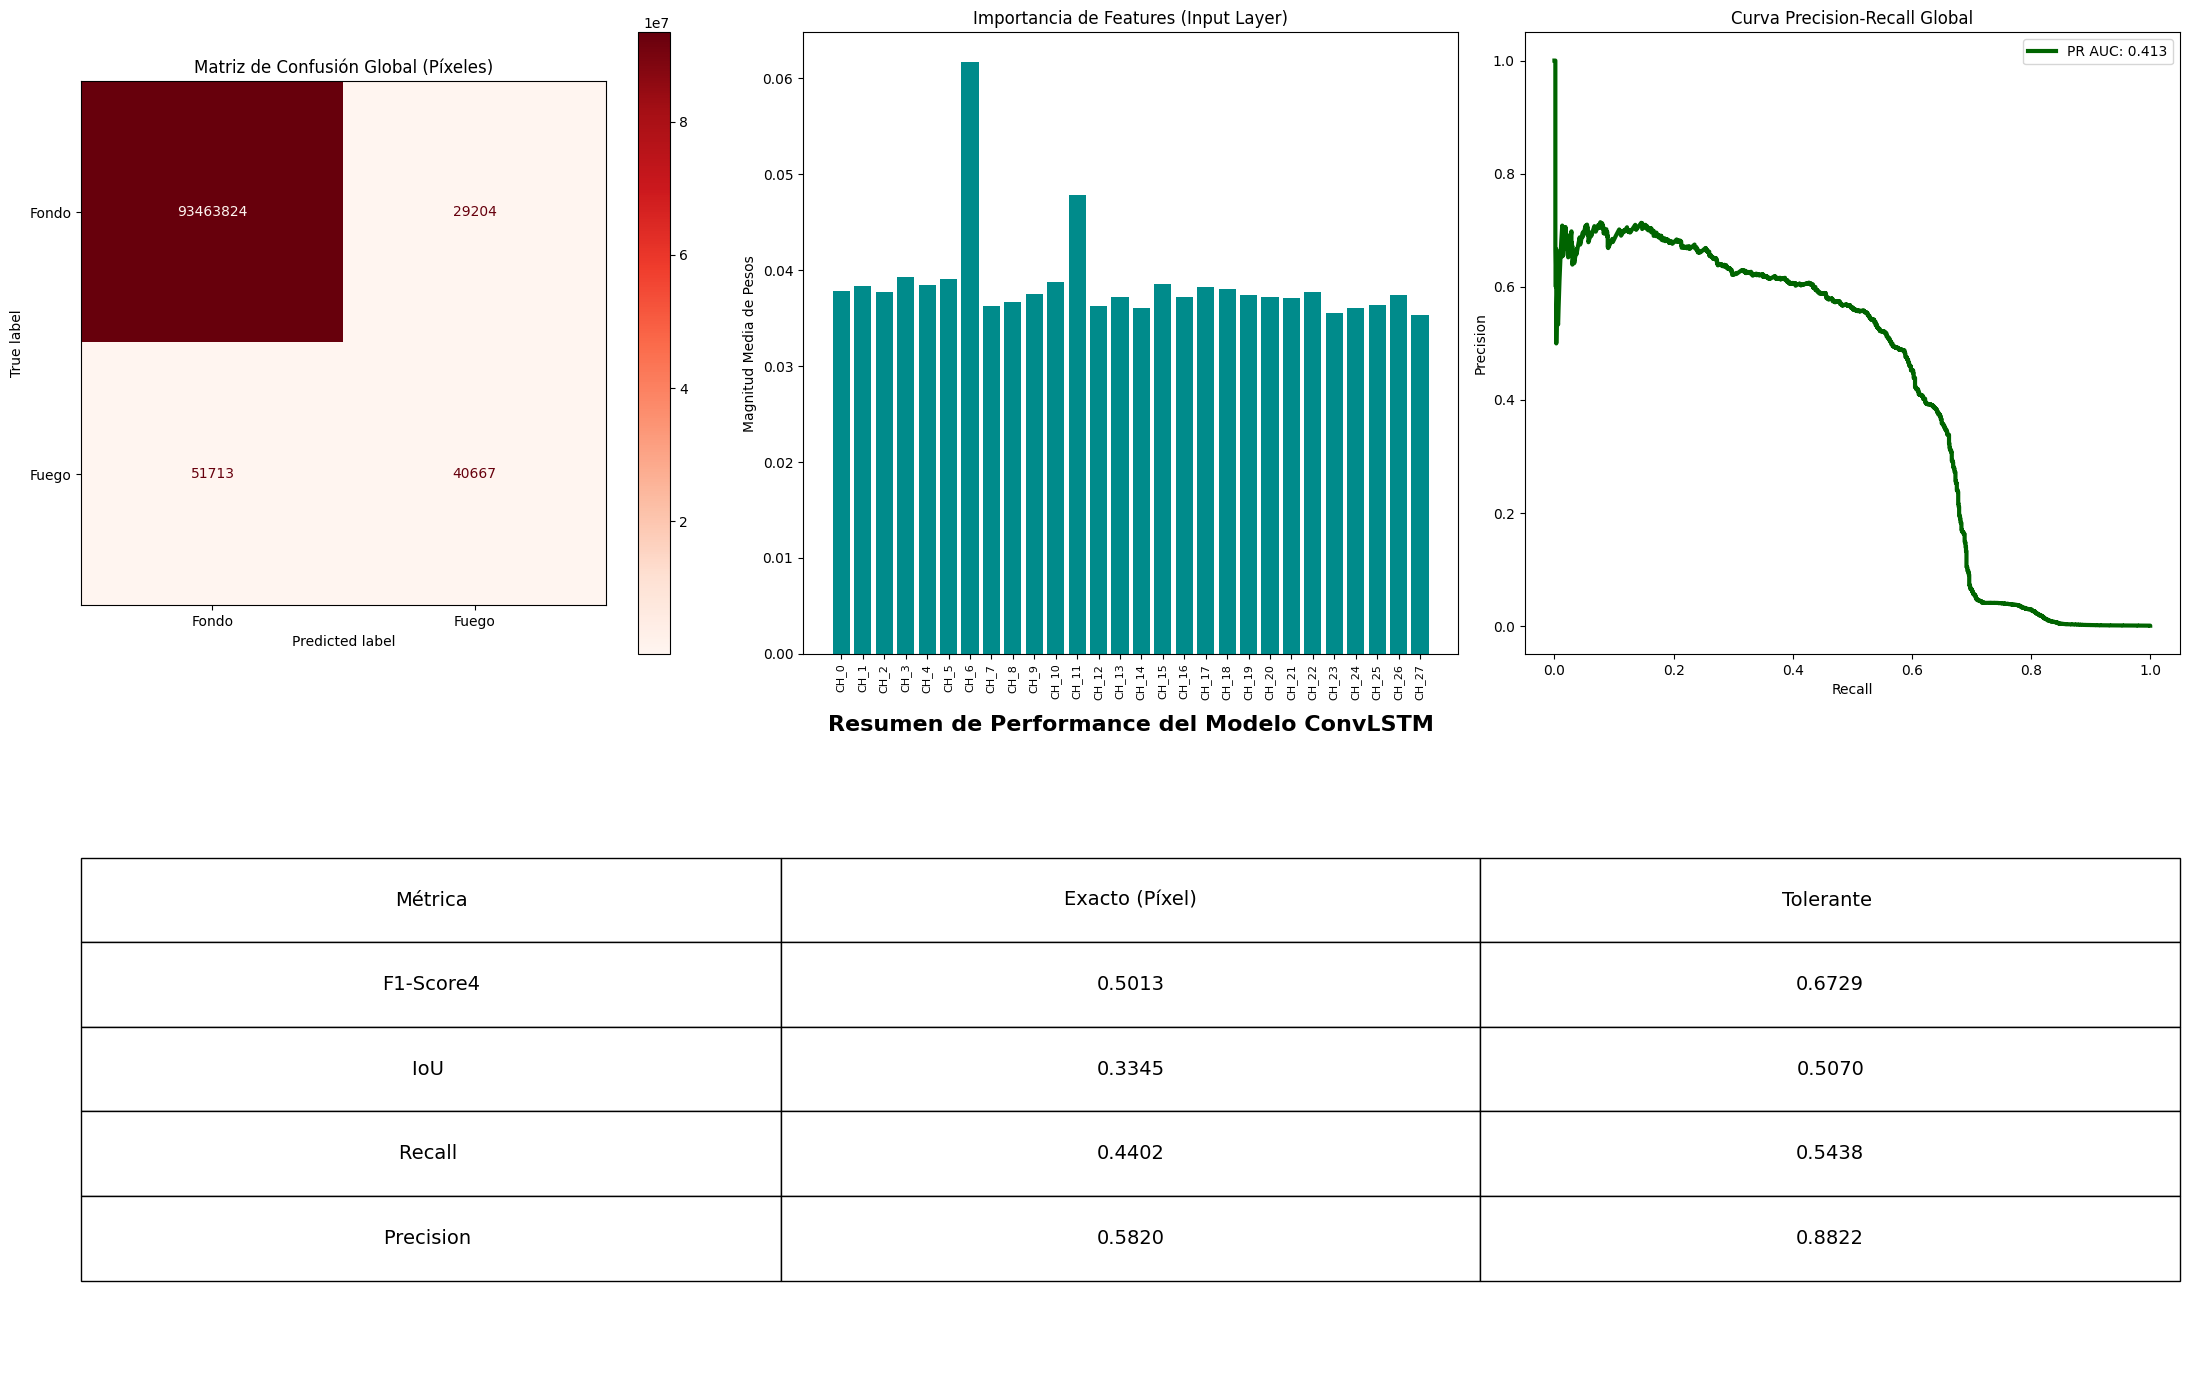

In [42]:


def get_tolerant_labels(y_true, pixels=2):
    """Dilata las etiquetas reales para permitir un margen de error espacial (Buffer)."""
    struct = ndimage.generate_binary_structure(2, 1)
    struct = ndimage.iterate_structure(struct, pixels)
    return ndimage.binary_dilation(y_true, structure=struct).astype(np.uint8)

def calc_metrics_group(tp, fp, fn):
    """Calcula el set estándar de métricas de segmentación."""
    prec = tp / (tp + fp + 1e-7)
    rec = tp / (tp + fn + 1e-7)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    return prec, rec, f1, iou


input_shape = (3, 256, 256, 28)
model = build_convlstm_bottleneck128(input_shape=input_shape)
weights_path = "saved/checkpoints/best_fire_model8_convlstm.weights.h5"

if Path(weights_path).exists():
    model.load_weights(weights_path)
    print(f"[*] Pesos cargados correctamente desde {weights_path}")
else:
    print("[!] Error: No se encontraron los pesos en la ruta especificada.")
    raise

ds_inference = InferenceTS(path_valid=test, cache_dir=cache_base/'test')


metrics_accum = {
    'tp_ex': 0, 'fp_ex': 0, 'fn_ex': 0, 'tn_ex': 0,
    'tp_tol': 0, 'fp_tol': 0, 'fn_tol': 0
}

all_probs = []  
all_targets = []
output_vis_dir = Path("inference_results")
output_vis_dir.mkdir(exist_ok=True)


first_layer_weights = model.layers[1].get_weights()[0]

feature_importance_global = np.mean(np.abs(first_layer_weights), axis=(0, 1, 3))

print(f"Iniciando Inferencia Completa en {len(ds_inference)} muestras...")


for i in tqdm(range(len(ds_inference))):
    sample = ds_inference[i]
    patches = sample["patches"]
    sample_id = sample["sample_id"]
    
    #  Predicción y GT
    pred_probs = ds_inference.predict_full_image(model, patches)
    y_true_512 = ds_inference.get_ground_truth(i)
    
    y_true_bin = (y_true_512 > 0).astype(np.uint8)
    y_pred_bin = (pred_probs > 0.5).astype(np.uint8)
    y_true_tol = get_tolerant_labels(y_true_bin, pixels=2)

    #  Contadores Exactos
    tp_e = np.sum((y_pred_bin == 1) & (y_true_bin == 1))
    fp_e = np.sum((y_pred_bin == 1) & (y_true_bin == 0))
    fn_e = np.sum((y_pred_bin == 0) & (y_true_bin == 1))
    tn_e = np.sum((y_pred_bin == 0) & (y_true_bin == 0))

    # Contadores Tolerantes
    tp_t = np.sum((y_pred_bin == 1) & (y_true_tol == 1))
    fp_t = np.sum((y_pred_bin == 1) & (y_true_tol == 0))
   
    fn_t = fn_e 

 
    metrics_accum['tp_ex'] += tp_e; metrics_accum['fp_ex'] += fp_e
    metrics_accum['fn_ex'] += fn_e; metrics_accum['tn_ex'] += tn_e
    metrics_accum['tp_tol'] += tp_t; metrics_accum['fp_tol'] += fp_t
    metrics_accum['fn_tol'] += fn_t

    if i % 3 == 0:
        all_probs.append(pred_probs.flatten()[::25])
        all_targets.append(y_true_bin.flatten()[::25])


    if (np.sum(y_true_bin) > 0 or np.sum(y_pred_bin) > 0) and i % 10 == 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(y_true_bin, cmap='inferno'); axes[0].set_title("GT")
        axes[1].imshow(pred_probs, cmap='inferno'); axes[1].set_title("Pred")
        err = np.zeros((512, 512, 3))
        err[..., 1] = (y_pred_bin * y_true_bin) # Verde: TP
        err[..., 0] = (y_pred_bin * (1 - y_true_tol)) # Rojo: FP
        err[..., 2] = (y_true_bin * (1 - y_pred_bin)) # Azul: FN
        axes[2].imshow(err); axes[2].set_title("Error (V:TP, R:FP, A:FN)")
        plt.savefig(output_vis_dir / f"sample_{sample_id}.png")
        plt.close()



p_ex, r_ex, f1_ex, iou_ex = calc_metrics_group(metrics_accum['tp_ex'], metrics_accum['fp_ex'], metrics_accum['fn_ex'])
p_tol, r_tol, f1_tol, iou_tol = calc_metrics_group(metrics_accum['tp_tol'], metrics_accum['fp_tol'], metrics_accum['fn_tol'])


all_targets_cat = np.concatenate(all_targets)
all_probs_cat = np.concatenate(all_probs)

fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(2, 3)


ax0 = fig.add_subplot(gs[0, 0])
cm = np.array([[metrics_accum['tn_ex'], metrics_accum['fp_ex']], 
               [metrics_accum['fn_ex'], metrics_accum['tp_ex']]])
ConfusionMatrixDisplay(cm, display_labels=['Fondo', 'Fuego']).plot(ax=ax0, cmap='Reds', values_format='d')
ax0.set_title("Matriz de Confusión Global (Píxeles)")


ax1 = fig.add_subplot(gs[0, 1])
ch_indices = np.arange(28)
ax1.bar(ch_indices, feature_importance_global, color='darkcyan')
ax1.set_xticks(ch_indices)
ax1.set_xticklabels([f"CH_{i}" for i in ch_indices], rotation=90, fontsize=8)
ax1.set_title("Importancia de Features (Input Layer)")
ax1.set_ylabel("Magnitud Media de Pesos")


ax2 = fig.add_subplot(gs[0, 2])
prec_c, rec_c, _ = precision_recall_curve(all_targets_cat, all_probs_cat)
ax2.plot(rec_c, prec_c, color='darkgreen', lw=3, label=f'PR AUC: {auc(rec_c, prec_c):.3f}')
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Curva Precision-Recall Global")
ax2.legend()


ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')
metric_data = [
    ["F1-Score", f"{f1_ex:.4f}", f"{f1_tol:.4f}"],
    ["IoU ", f"{iou_ex:.4f}", f"{iou_tol:.4f}"],
    ["Recall ", f"{r_ex:.4f}", f"{r_tol:.4f}"],
    ["Precision ", f"{p_ex:.4f}", f"{p_tol:.4f}"]
]
table = ax3.table(cellText=metric_data, colLabels=["Métrica", "Exacto", "Tolerante"], 
                  loc='center', cellLoc='center')
table.scale(1, 4)
table.set_fontsize(14)
ax3.set_title("Resumen de Performance del Modelo ConvLSTM", pad=20, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

pd.DataFrame([metrics_accum]).to_csv("pixel_counts_final.csv", index=False)

In [ ]:
cp saved/checkpoints/best_fire_model8_convlstm.weights.h5 .

In [39]:

test_dataset = TSDataset(
    path_valid=test,
    cache_dir=cache_base/'test',      
    crop_size=CROP_SIZE,
    stride_t=STRIDE_T,
    #force_rebuild=True
)
test_tf_ds = prepare_tf_dataset(test_dataset, batch_size=BATCH_SIZE, is_train=False)



[*] Pesos cargados correctamente desde saved/checkpoints/best_fire_model9_convlstm.weights.h5
Cargando catálogo plano desde saved/data_cache/test/catalog_flat_s3_st1_c256.json...
Dataset listo: 357 muestras.


In [49]:

def evaluate_and_save_all_viz(model, tf_dataset, steps, output_dir="inference_results_full", threshold=0.5):
    viz_path = Path(output_dir)
    omisiones_path = viz_path / "omisiones"
    falsas_path = viz_path / "falsas_alarmas"
    
    for p in [viz_path, omisiones_path, falsas_path]:
        p.mkdir(parents=True, exist_ok=True)

    y_true_all = []
    y_pred_all = []
    img_true_bin = []
    img_pred_bin = []

    img_counts = {
        'total_images': 0,
        'falsas_alarmas_img': 0,
        'omisiones_img': 0,
        'detecciones_ok_img': 0,
        'vacias_ok_img': 0
    }

    print(f"[*] Iniciando inferencia completa sobre {steps} pasos.")

    for b_idx, (x_batch, y_batch) in enumerate(tqdm(tf_dataset.take(steps))):
        preds = model.predict(x_batch, verbose=0)
        
        # Binarización
        preds_bin = (preds > threshold).astype(np.uint8)
        y_true_np = y_batch.numpy()
        y_true_bin = (y_true_np > 0).astype(np.uint8)

        # Guardar para métricas de píxeles
        y_true_all.append(y_true_bin.flatten())
        y_pred_all.append(preds_bin.flatten())

        batch_size_actual = x_batch.shape[0]
        for s_idx in range(batch_size_actual):
            img_counts['total_images'] += 1
            
           
            habia_fuego = np.any(y_true_bin[s_idx] == 1)
            dije_fuego = np.any(preds_bin[s_idx] == 1)
            
            img_true_bin.append(int(habia_fuego))
            img_pred_bin.append(int(dije_fuego))

            save_path = viz_path 
            etiqueta_error = ""


            if not habia_fuego and dije_fuego:
                img_counts['falsas_alarmas_img'] += 1
                save_path = falsas_path
                etiqueta_error = "FALSA ALARMA (FP)"
            elif habia_fuego and not dije_fuego:
                img_counts['omisiones_img'] += 1
                save_path = omisiones_path
                etiqueta_error = "OMISIÓN (FN)"
            elif habia_fuego and dije_fuego:
                img_counts['detecciones_ok_img'] += 1
                etiqueta_error = "DETECCIÓN OK (TP)"
            else:
                img_counts['vacias_ok_img'] += 1
                etiqueta_error = "VACÍO OK (TN)"


            img_name = f"batch_{b_idx:04d}_sample_{s_idx:02d}.png"
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            color_titulo = 'green' if "OK" in etiqueta_error else 'red'
            fig.suptitle(f"Análisis: {etiqueta_error}", fontsize=16, color=color_titulo)


            axes[0].imshow(y_true_bin[s_idx, ..., 0], cmap='inferno')
            axes[0].set_title(f"GT (Realidad)\n{'CON FUEGO' if habia_fuego else 'VACÍO'}")
            axes[0].axis('off')


            im1 = axes[1].imshow(preds[s_idx, ..., 0], cmap='inferno')
            axes[1].set_title(f"Predicción (Prob)\n{'DETECTADO' if dije_fuego else 'NADA'}")
            axes[1].axis('off')
            plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    
            # Verde: TP, Rojo: FP, Azul: FN
            error_map = np.zeros((y_true_bin.shape[1], y_true_bin.shape[2], 3))
            tp = (preds_bin[s_idx] == 1) & (y_true_bin[s_idx] == 1)
            fp = (preds_bin[s_idx] == 1) & (y_true_bin[s_idx] == 0)
            fn = (preds_bin[s_idx] == 0) & (y_true_bin[s_idx] == 1)
            
            error_map[..., 1] = tp[..., 0] # Verde
            error_map[..., 0] = fp[..., 0] # Rojo
            error_map[..., 2] = fn[..., 0] # Azul
            
            axes[2].imshow(error_map)
            axes[2].set_title("Mapa de Error\nVerde:TP, Rojo:FP, Azul:FN")
            axes[2].axis('off')

            plt.tight_layout()
            plt.savefig(save_path / img_name, dpi=100)
            plt.close(fig)


    y_true_flat = np.concatenate(y_true_all)
    y_pred_flat = np.concatenate(y_pred_all)

    # Matrices de Confusión
    cm_pixels = confusion_matrix(y_true_flat, y_pred_flat)
    cm_images = confusion_matrix(img_true_bin, img_pred_bin)

    # Visualización de Matrices
    fig_cm, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    sns.heatmap(cm_pixels, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title("Matriz de Confusión: Píxeles")
    axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

    sns.heatmap(cm_images, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title("Matriz de Confusión: Imágenes (Detección)")
    axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")
    
    plt.savefig(viz_path / "reporte_matrices_confusion.png")
    plt.show()

   
    prec = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    rec = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
    iou = jaccard_score(y_true_flat, y_pred_flat, zero_division=0)
    

    print("\n" + "="*50)
    print(f"       REPORT DE MÉTRICAS (Threshold: {threshold})")
    print("="*50)
    print(f"MÉTRICAS POR PÍXEL (CRECIMIENTO):")
    print(f"  - Precision:     {prec:.4f}")
    print(f"  - Recall:        {rec:.4f}")
    print(f"  - F1-Score:      {f1:.4f}")
    print(f"  - IoU (Jaccard): {iou:.4f}")
    print("-" * 50)
    print(f"MÉTRICAS POR IMAGEN (TOTAL: {img_counts['total_images']}):")
    print(f"  - Accuracy:      {accuracy_score(img_true_bin, img_pred_bin):.4f}")
    print(f"  - Falsas Alarmas: {img_counts['falsas_alarmas_img']}")
    print(f"  - Omisiones:      {img_counts['omisiones_img']}")
    print(f"  - Detecciones OK: {img_counts['detecciones_ok_img']}")
    print("="*50)

    return img_counts

In [49]:

     
steps_test = len(test_dataset) // BATCH_SIZE

results = evaluate_and_save_all_viz(model, test_tf_ds, steps=steps_test)

[*] Iniciando inferencia completa.
[*] Carpeta de omisiones: inference_results_full/omisiones


100%|██████████| 44/44 [03:01<00:00,  4.12s/it]



REPORT FINAL DE INFERENCIA
MÉTRICAS DE PÍXELES:
  F1-Score:  0.5739
  IoU:       0.4025
---------------------------------------------
MÉTRICAS DE IMÁGENES (TOTAL: 352):
  [!] Falsas Alarmas (Revisar en /falsas_alarmas): 10
  [!] Omisiones (Revisar en /omisiones):           38
  [+] Detecciones Correctas:                        225
  [+] Fotos Vacías Correctas:                       79


In [51]:
import shutil


folder_to_zip = '/kaggle/working/inference_results_full'

output_filename = 'mis_predicciones'

shutil.make_archive(output_filename, 'zip', folder_to_zip)

print(f"Archivo {output_filename}.zip creado")

Archivo mis_predicciones.zip creado


In [44]:
!rm -rf saved/data_cache

In [41]:

class TSDataset1(TSDataset):
    def __init__(
        self,**kwargs
    ):
        super().__init__(**kwargs)

    def _load_single_window(self, info):
        region = self.raw_paths[info["region"]]
        dates = info["dates"]
        
        seq_x = []
        last_input_fire = None 

        # Las primeras N fechas son la entrada (X)
        for idx, t_date in enumerate(dates[:-1]):
            with rasterio.open(region["VIIRS_Day"][t_date]) as dsrc:
                y0, x0 = (dsrc.height - self.crop_size)//2, (dsrc.width - self.crop_size)//2
                win = rasterio.windows.Window(x0, y0, self.crop_size, self.crop_size)
                
                day = self._normalize(dsrc.read([1,2,3,4,5,6], window=win))
                fire_today = self._normalize(dsrc.read([7], window=win), is_label=True)
                
                
                if idx == len(dates[:-1]) - 1:
                    last_input_fire = fire_today.copy()
            
            with rasterio.open(region["FirePred"][t_date]) as fsrc:
                firep = self._normalize(fsrc.read(window=win))

            # VIIRS_NIGHT 
            if t_date in region["VIIRS_Night"]:
                with rasterio.open(region["VIIRS_Night"][t_date]) as nsrc:
                    night = self._normalize(nsrc.read(window=win)[-2:])
            else:
                idx_actual = dates.index(t_date)
                date_prev = dates[idx_actual - 1]
                date_next = dates[idx_actual + 1]
                #interpolar
                with rasterio.open(region["VIIRS_Night"][date_prev]) as s1, \
                     rasterio.open(region["VIIRS_Night"][date_next]) as s2:
                    night = (self._normalize(s1.read(window=win)[-2:]) + 
                             self._normalize(s2.read(window=win)[-2:])) / 2.0
            
            x_combined = np.concatenate([day, fire_today, night, firep], axis=0)
            seq_x.append(x_combined)

        # Target
        target_date = dates[-1]
        with rasterio.open(region["VIIRS_Day"][target_date]) as dsrc:
            # Estado del fuego t+1 (final_label)
            final_label = self._normalize(dsrc.read([7], window=win), is_label=True)
        
        # crec = (t+1 == 1) Y (t == 0)
        # last_input_fire es t, final_label es t+1
        net_growth_label = np.where(np.logical_and(last_input_fire == 0, final_label > 0), 1.0, 0.0)

        return np.stack(seq_x), net_growth_label.astype(np.float32)
        




In [45]:


cache_base = Path(BASE_CACHE_DIR)


train_dataset = TSDataset1(
    path_valid=train,
    cache_dir=cache_base/'train',      
    crop_size=CROP_SIZE,
    stride_t=STRIDE_T,
    #force_rebuild=True
)

val_dataset = TSDataset1(
    path_valid=val,
    cache_dir=cache_base/'val',
    crop_size=CROP_SIZE,
    seq_len =INPUT_SEQ_LEN,
    stride_t=STRIDE_T,
    #force_rebuild=True
)


train_tf_ds = prepare_tf_dataset(train_dataset, batch_size=BATCH_SIZE, is_train=True)
val_tf_ds = prepare_tf_dataset(val_dataset, batch_size=BATCH_SIZE, is_train=False)
main(train_tf_ds,val_tf_ds)

Generando catálogo ...
Dataset listo: 1966 muestras.
Generando catálogo ...
Dataset listo: 239 muestras.
[*] Historial cargado. Reanudando en época 24
[*] Mejor val_f1 histórico: 0.3067
[*] Cargando pesos recientes: saved/checkpoints/last_model_convlstm9.weights.h5

Iniciando entrenamiento
Epoch 24/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9959 - f1_score: 0.3529 - fn: 135089.4844 - iou: 0.2144 - loss: 0.6533 - precision: 0.3422 - recall: 0.3656 - tol_f1_score: 0.4638 - tol_fn: 0.4753 - tol_recall: 0.4383
Epoch 24: val_f1_score did not improve from 0.30669

Epoch 24: saving model to saved/checkpoints/last_model_convlstm9.weights.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 2843s 11s/step - accuracy: 0.9959 - f1_score: 0.3529 - fn: 135610.5469 - iou: 0.2144 - loss: 0.6533 - precision: 0.3422 - recall: 0.3656 - tol_f1_score: 0.4638 - tol_fn: 0.4753 - tol_recall: 0.4383 - val_accuracy: 0.9968 - val_f1_score: 0.2995 - val_fn: 24378.0000 - val_iou: 0.1761 - val_loss: 0.7656 - val_precisi

KeyboardInterrupt: 

[*] Pesos cargados correctamente desde saved/checkpoints/best_fire_model9_convlstm.weights.h5
Cargando catálogo plano desde saved/data_cache/test/catalog_flat_s3_st1_c256.json...
Dataset listo: 357 muestras.
[*] Iniciando inferencia completa sobre 44 pasos.


100%|██████████| 44/44 [03:39<00:00,  4.99s/it]


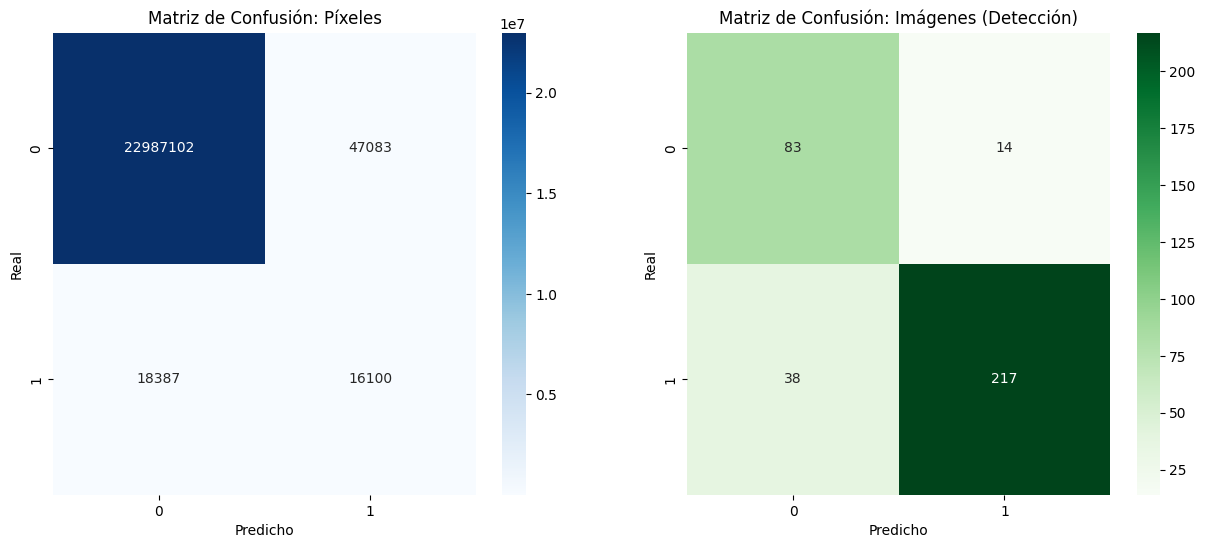


       REPORT DE MÉTRICAS (Threshold: 0.5)
MÉTRICAS POR PÍXEL (CRECIMIENTO):
  - Precision:     0.2548
  - Recall:        0.4668
  - F1-Score:      0.3297
  - IoU (Jaccard): 0.1974
--------------------------------------------------
MÉTRICAS POR IMAGEN (TOTAL: 352):
  - Accuracy:      0.8523
  - Falsas Alarmas: 14
  - Omisiones:      38
  - Detecciones OK: 217


In [50]:
input_shape = (3, 256, 256, 28)
model = build_convlstm_bottleneck128(input_shape=input_shape)
weights_path = "saved/checkpoints/best_fire_model9_convlstm.weights.h5"

if Path(weights_path).exists():
    model.load_weights(weights_path)
    print(f"[*] Pesos cargados correctamente desde {weights_path}")
else:
    print("[!] Error: No se encontraron los pesos en la ruta especificada.")
    raise
test_dataset = TSDataset1(
    path_valid=test,
    cache_dir=cache_base/'test',      
    crop_size=CROP_SIZE,
    stride_t=STRIDE_T,
    #force_rebuild=True
)
test_tf_ds = prepare_tf_dataset(test_dataset, batch_size=BATCH_SIZE, is_train=False)

steps_test = len(test_dataset) // BATCH_SIZE


results = evaluate_and_save_all_viz(model, test_tf_ds, steps=steps_test)